In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('df_finale_pulito.csv')
df['codice_comune'] = df['codice_comune'].astype(str).str.zfill(6)
df

# carico il dataset pulito salvato nel notebook di preparazione. il csv non
# conserva il tipo delle colonne, quindi il codice_comune (che avevo salvato
# come stringa a 6 cifre) viene riletto come intero e perde gli zeri davanti
# (001001 diventa 1001). lo riporto subito a stringa con zfill, così resta
# coerente e posso riusarlo come chiave senza problemi

,codice_comune,anno,feriti,morti,incidenti,comune,sigla,superficie_kmq,popolazione,incidenti_per_kmq,incidenti_per_1000_abitanti
0,001001,2001,10,0,5,Agliè,TO,13.1462,2557,0.38,1.96
1,001001,2002,10,0,5,Agliè,TO,13.1462,2538,0.38,1.97
2,001001,2003,7,0,4,Agliè,TO,13.1462,2588,0.30,1.55
3,001001,2004,13,0,9,Agliè,TO,13.1462,2679,0.68,3.36
4,001001,2005,2,0,2,Agliè,TO,13.1462,2674,0.15,0.75
...,...,...,...,...,...,...,...,...,...,...,...
184556,111107,2019,5,0,5,Villaspeciosa,SU,27.1937,2605,0.18,1.92
184557,111107,2020,3,0,2,Villaspeciosa,SU,27.1937,2549,0.07,0.78
184558,111107,2021,7,0,5,Villaspeciosa,SU,27.1943,2536,0.18,1.97
184559,111107,2022,1,0,1,Villaspeciosa,SU,27.1943,2575,0.04,0.39


In [3]:
df.info()
df.describe()

# lancio .info() e .describe() per controllare che sia tutto congruente con quanto fatto prima.
# anche qui vedo una deviazione standard molto più alta della media per quanto riguarda feriti e n° di incidenti,
# segno che il pattern di dati è rimasto intatto, come già visto nell'altro notebook,
# sono solo più puliti e meglio rappresentati. ci tengo a ricordare che ho escluso il 2024
# perchè aveva il 20% di comuni in meno rispetto al 2023 e questo mi avrebbe potuto portare
# ad un errata rappresentazione dei dati

<class 'pandas.DataFrame'>
RangeIndex: 184561 entries, 0 to 184560
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   codice_comune                184561 non-null  str    
 1   anno                         184561 non-null  int64  
 2   feriti                       184561 non-null  int64  
 3   morti                        184561 non-null  int64  
 4   incidenti                    184561 non-null  int64  
 5   comune                       184538 non-null  str    
 6   sigla                        182445 non-null  str    
 7   superficie_kmq               184561 non-null  float64
 8   popolazione                  184561 non-null  int64  
 9   incidenti_per_kmq            184561 non-null  float64
 10  incidenti_per_1000_abitanti  184561 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 15.5 MB


,anno,feriti,morti,incidenti,superficie_kmq,popolazione,incidenti_per_kmq,incidenti_per_1000_abitanti
count,184561.000000,184561.000000,184561.000000,184561.000000,184561.000000,1.845610e+05,184561.000000,184561.000000
mean,2011.938920,35.034541,0.535238,24.921787,37.563161,7.366364e+03,0.709254,1.980402
std,6.625345,340.079145,2.804796,258.693771,50.233277,4.083294e+04,2.065203,2.366082
min,2001.000000,0.000000,0.000000,0.000000,0.120600,2.800000e+01,0.000000,0.000000
25%,2006.000000,1.000000,0.000000,1.000000,11.292500,1.017000e+03,0.020000,0.390000
50%,2012.000000,5.000000,0.000000,3.000000,22.018800,2.413000e+03,0.150000,1.480000
75%,2018.000000,18.000000,0.000000,12.000000,43.648500,6.054000e+03,0.560000,2.790000
max,2023.000000,30254.000000,363.000000,23135.000000,1288.187500,2.820219e+06,99.220000,175.310000


# Distribuzione degli incidenti tra i comuni

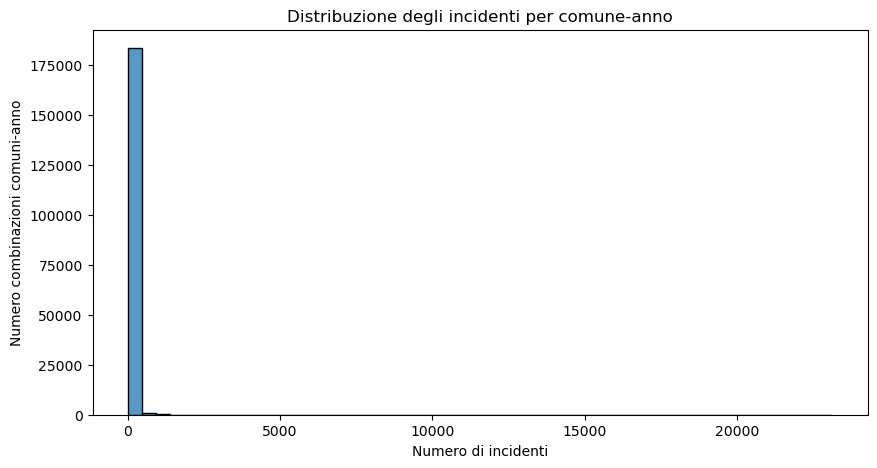

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['incidenti'], bins=50)
plt.title('Distribuzione degli incidenti per comune-anno')
plt.xlabel('Numero di incidenti')
plt.ylabel('Numero combinazioni comuni-anno')
plt.show()

# faccio l'istogramma degli incidenti, ma viene illeggibile, si vede solo una
# barra altissima schiacciata a sinistra e il resto vuoto. all'inizio non
# capivo perché, poi mi sono ricordato degli outlier visti nell'altro notebook,
# tipo Roma Capitale con oltre 23000 incidenti. sono proprio loro che con
# numeri così enormi allungano l'asse fino a 23000 e schiacciano tutti gli
# altri comuni in un'unica barra. quindi il grafico normale non va bene per
# questi dati così sbilanciati

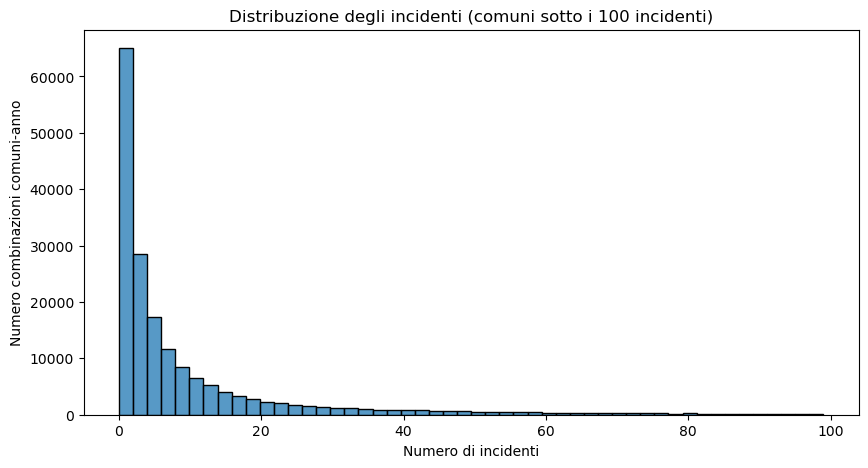

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['incidenti'] < 100]['incidenti'], bins=50)
plt.title('Distribuzione degli incidenti (comuni sotto i 100 incidenti)')
plt.xlabel('Numero di incidenti')
plt.ylabel('Numero combinazioni comuni-anno')
plt.show()

# per leggere meglio escludo i pochi grandi centri (sopra i 100 incidenti) e metto nel
# grafico solo il grosso dei record. così vedo bene come si distribuisce la
# maggioranza, infatti si veodno tantissime righe comune-anno con pochissimi incidenti e la curva che cala
# in fretta. gli outlier ovviamente non li ho cancellati dai dati, li ho solo tolti da
# questo grafico per renderlo leggibile

# Andamento degli incidenti nel tempo (2001-2023)

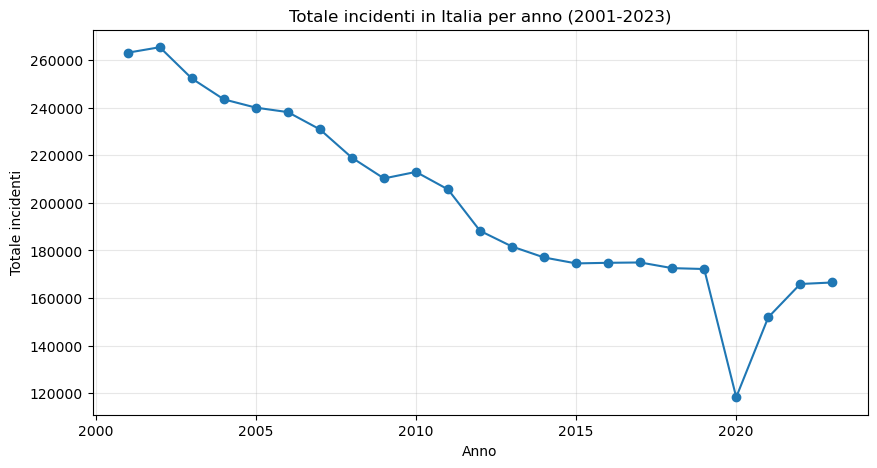

In [6]:
incidenti_per_anno = df.groupby('anno')['incidenti'].sum()
incidenti_per_anno.plot(marker='o', figsize=(10, 5))

plt.title('Totale incidenti in Italia per anno (2001-2023)')
plt.xlabel('Anno')
plt.ylabel('Totale incidenti')
plt.grid(True, alpha=0.3)
plt.show()

# raggruppo per anno e sommo gli incidenti di tutti i comuni, ottenendo il
# totale nazionale anno per anno. poi con .plot() faccio direttamente il grafico
# a linea, pandas è intelligente e mette da solo gli anni sull'asse orizzontale e i totali su
# quello verticale. marker='o' aggiunge un pallino su ogni anno per leggere
# meglio i punti

Il totale degli incidenti in Italia cala in modo abbastanza costante dal 2001 al 2019, probabilmente grazie a strade e auto più sicure e a controlli più severi negli anni. nel 2020 c'è un crollo evidente, fino a circa 118.000 incidenti: è quasi sicuramente l'effetto del lockdown per il Covid, con le strade molto più vuote e quindi molti meno incidenti, dal 2021 il numero risale, ma per fortuna senza tornare ai livelli di prima della pandemia

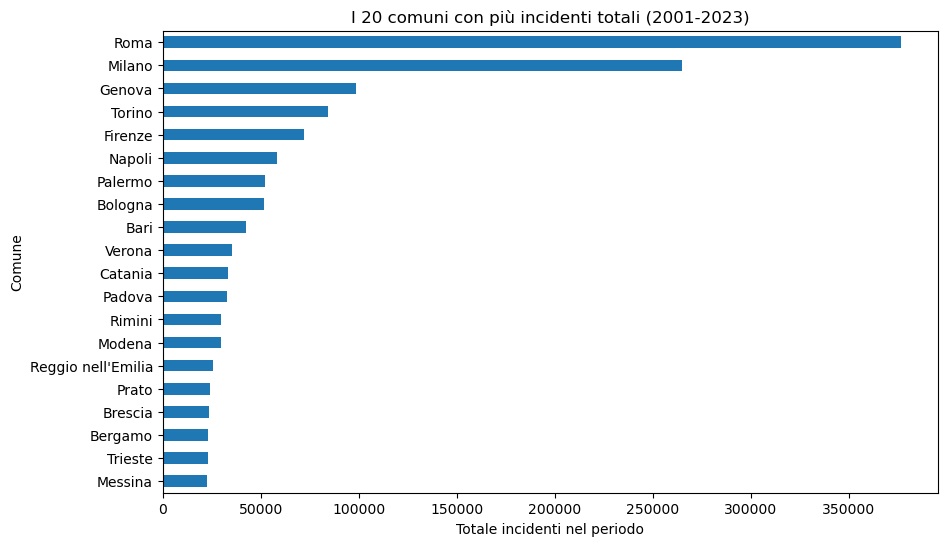

In [7]:
top_comuni = df.groupby('comune')['incidenti'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_comuni.sort_values().plot(kind='barh')
plt.title('I 20 comuni con più incidenti totali (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Comune')
plt.show()

# voglio sapere quanti e quali sono i comuni con più incidenti.
# raggruppo per comune e sommo gli incidenti dei 23 anni, poi prendo i 20 con
# il totale più alto e li metto in un grafico a barre orizzontali.
# mi aspetto le grandi città in cima (Roma, Milano...), perché più
# popolazione e più traffico significano più incidenti in valore assoluto

# Verifica

Dal grafico qui sopra vedo che i comuni con più incidenti in assoluto sono tutte grandi città, Roma e Milano staccano nettamente, seguite da Genova, Torino, Firenze, Napoli e altri capoluoghi. Più popolazione e più traffico significano più incidenti in valore assoluto, ovviamente.

La domanda che mi sorge spontanea è: "se le grandi città hanno così tanti incidenti, magari qualcun altro avrà già pensato a investirci prima di noi?". Avendo più popolazione e più risorse, è lecito pensare che siano già presenti aziende che lavorano nel nostro stesso settore.

Questo è sostenuto dal modo in cui sono strutturati gli investimenti pubblici, che seguono delle fasce di popolazione. Da un lato i comuni piccoli sotto i 5.000 abitanti hanno un fondo dedicato per la sicurezza stradale (art. 19 D.L. 104/2023). Dall'altro, le grandi città attingono a canali propri come i fondi PNRR per la rigenerazione urbana, rivolti ai comuni sopra i 15.000 abitanti, ai comuni sopra i 60.000 (programma PINQUA) e alle 14 città metropolitane (Piani Urbani Integrati). Quindi grandi e piccoli centri hanno strade di finanziamento separate.

Va però detto che questi fondi sono recenti (il fondo piccoli comuni è del 2023, il PNRR del 2021 in poi) e non c'entrano con l'andamento storico degli incidenti che ho analizzato dal 2001. Li cito non per spiegare il passato, ma perché fotografano com'è strutturato il mercato oggi, e la decisione di dove investire la prenderei adesso, non vent'anni fa. Resta comunque un'ipotesi di mercato, non una cosa che posso dimostrare con i miei dati ISTAT (che mi dicono quanti incidenti ci sono, non chi ci sta già investendo).

La domanda allora è: ha senso aprire dove la concorrenza è probabilmente già stabilita, o è meglio concentrarsi su comuni più piccoli ma comunque pericolosi, dove magari c'è meno presidio?

Fonti:
- Fondo investimenti stradali nei piccoli Comuni (art. 19 D.L. 104/2023): https://trasparenza.mit.gov.it/archivio28_provvedimenti-amministrativi_0_220080_726_1.html
- Investimenti PNRR per le città metropolitane: https://lentepubblica.it/buone-pratiche/pnrr-rigenerazione-urbana-investimenti-citta-metropolitane-2024/

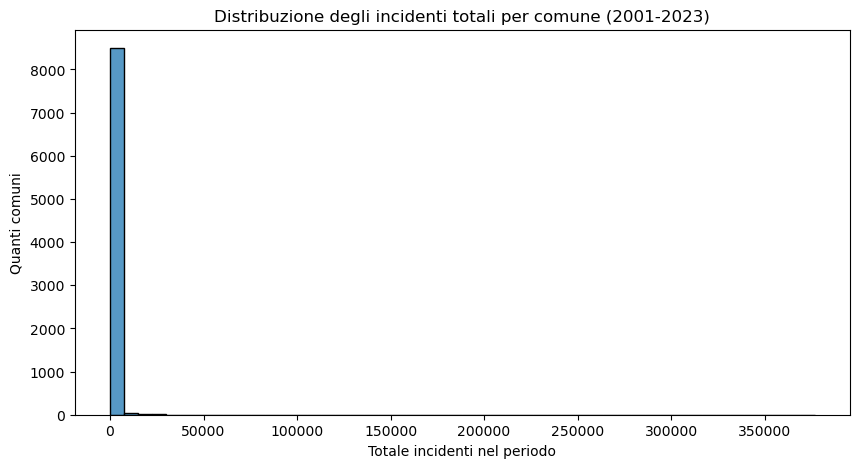

In [8]:
incidenti_per_comune = df.groupby('codice_comune')['incidenti'].sum()

plt.figure(figsize=(10, 5))
sns.histplot(incidenti_per_comune, bins=50)
plt.title('Distribuzione degli incidenti totali per comune (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Quanti comuni')
plt.show()

# sommo gli incidenti di tutti gli anni per ogni comune, poi faccio l'istogramma
# di questi totali. come prima, mi aspetto una forma molto sbilanciata dove ci sono tanti
# comuni con totali bassi e pochi grandi centri con totali enormi. guardo dove
# la maggioranza si concentra per scegliere una soglia con cui escludere le
# grandi città nel grafico dopo

In [9]:
incidenti_per_comune = df.groupby('codice_comune')['incidenti'].sum()
print(incidenti_per_comune.quantile([0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]))

# sommo gli incidenti dei 23 anni per comune e guardo i percentili alti. all'inizio
# avevo visto solo il valore sotto cui stanno il 90%, 95%, 98%, 99% dei comuni, poi ho aumentato la granularità
# per avere un quadro più completo. sta cosa mi serve per trovare
# una soglia con cui separare i pochi grandi centri (i percentili più alti)
# dal grosso dei comuni, e poi rifare la classifica solo su questi ultimi

0.90     791.00
0.91     879.86
0.92     994.00
0.93    1133.78
0.94    1314.24
0.95    1543.10
0.96    1892.96
0.97    2446.72
0.98    3636.54
0.99    6386.16
Name: incidenti, dtype: float64


In [10]:
print("soglia 90° (791):", len(incidenti_per_comune[incidenti_per_comune < 791]), "comuni")
print("soglia 91° (880):", len(incidenti_per_comune[incidenti_per_comune < 880]), "comuni")
print("soglia 92° (994):", len(incidenti_per_comune[incidenti_per_comune < 994]), "comuni")
print("soglia 93° (1134):", len(incidenti_per_comune[incidenti_per_comune < 1134]), "comuni")
print("soglia 94° (1314):", len(incidenti_per_comune[incidenti_per_comune < 1314]), "comuni")
print("soglia 95° (1543):", len(incidenti_per_comune[incidenti_per_comune < 1543]), "comuni")
print("soglia 96° (1893):", len(incidenti_per_comune[incidenti_per_comune < 1893]), "comuni")
print("soglia 97° (2447):", len(incidenti_per_comune[incidenti_per_comune < 2447]), "comuni")
print("soglia 98° (3637):", len(incidenti_per_comune[incidenti_per_comune < 3637]), "comuni")
print("soglia 99° (6386):", len(incidenti_per_comune[incidenti_per_comune < 6386]), "comuni")
print("comuni totali:", len(incidenti_per_comune))

# per ogni soglia conto quanti comuni restano sotto, usando il filtro e len().
# così vedo quanti comuni "tengo" a seconda di dove taglio: più la soglia è
# bassa, più grandi/medie città escludo. ho messo il n° totale di comuni per avere un
# metro di paragone visivo

soglia 90° (791): 7715 comuni
soglia 91° (880): 7802 comuni
soglia 92° (994): 7887 comuni
soglia 93° (1134): 7973 comuni
soglia 94° (1314): 8059 comuni
soglia 95° (1543): 8145 comuni
soglia 96° (1893): 8231 comuni
soglia 97° (2447): 8316 comuni
soglia 98° (3637): 8402 comuni
soglia 99° (6386): 8488 comuni
comuni totali: 8574


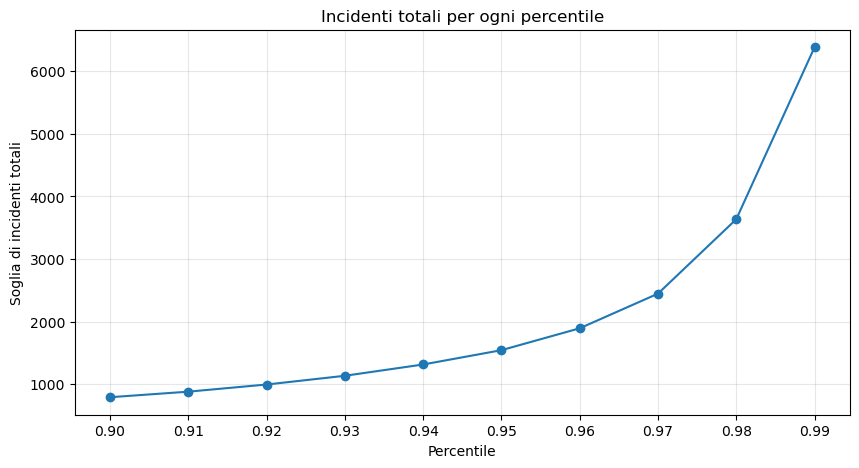

In [11]:
percentili = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
valori = incidenti_per_comune.quantile(percentili)

plt.figure(figsize=(10, 5))
plt.plot(percentili, valori.values, marker='o')
plt.title('Incidenti totali per ogni percentile')
plt.xlabel('Percentile')
plt.ylabel('Soglia di incidenti totali')
plt.xticks(percentili)
plt.grid(True, alpha=0.3)
plt.show()

# qui metto a grafico il valore di ogni percentile dal 90° al 99° per vedere con gli
# occhi quello che avevo notato nei numeri. la curva sale tranquilla fino al
# 96-97°, poi da lì in poi parte verso l'alto, è il punto dove iniziano i
# grandi centri con i totali enormi, quelli che voglio togliere, ma per interpretare ancora meglio
# vorrei aumentare di nuovo un po' la granularità dal 97% in poi

0.970     2446.720
0.975     3010.150
0.980     3636.540
0.985     4440.365
0.990     6386.160
0.995    12225.930
Name: incidenti, dtype: float64


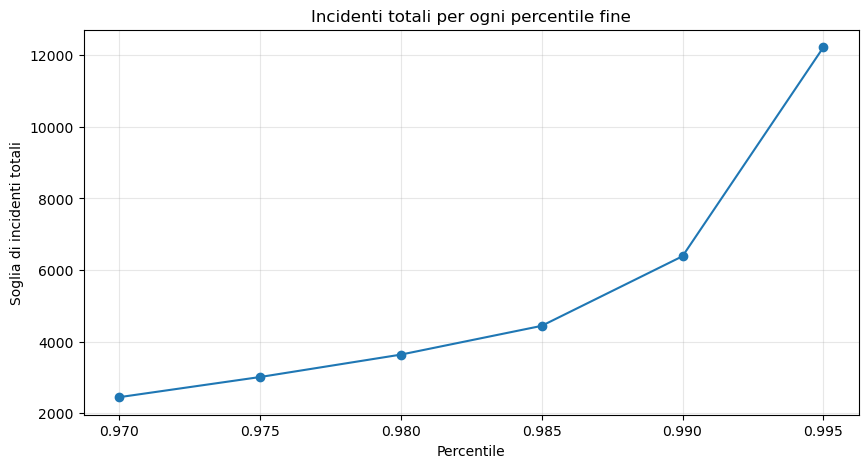

In [12]:
percentili_fini = [0.970, 0.975, 0.980, 0.985, 0.990, 0.995]
valori_fini = incidenti_per_comune.quantile(percentili_fini)
print(valori_fini)

plt.figure(figsize=(10, 5))
plt.plot(percentili_fini, valori_fini.values, marker='o')
plt.title('Incidenti totali per ogni percentile fine')
plt.xlabel('Percentile')
plt.ylabel('Soglia di incidenti totali')
plt.xticks(percentili_fini)
plt.grid(True, alpha=0.3)
plt.show()

# zoomo sulla zona calda tra il 97° e il 99.5° percentile, dove la curva si
# impenna, per guardare più da vicino come crescono i valori e scegliere la
# soglia con più consapevolezza. mi aspetto di rivedere l'impennata anche qui
# è una distribuzione così sbilanciata che a ogni zoom la coda sale sempre più
# ripida verso gli ultimi grandi centri

In [13]:
soglia = incidenti_per_comune.quantile(0.985)
soglia = int(soglia)
print("soglia 98,5°:", soglia, "incidenti")
print("comuni tenuti:", len(incidenti_per_comune[incidenti_per_comune < soglia]))
print("comuni esclusi:", len(incidenti_per_comune[incidenti_per_comune >= soglia]))

# calcolo la soglia del 98,5° percentile e la converto in intero, perché è un
# numero di incidenti e un incidente a metà non esiste. poi conto quanti comuni
# restano sotto questa soglia (quelli che tengo) e quanti sopra (i grandi centri
# che escludo)

soglia 98,5°: 4440 incidenti
comuni tenuti: 8445
comuni esclusi: 129


# Verifica effettuata
Dopo aver guardato i percentili con sempre più dettaglio ho deciso di tagliare al percentile 98,5, che corrisponde a 4440 incidenti totali. Più o meno è il punto dove la curva smette di salire piano e inizia a impennarsi, quindi oltre quella soglia rimangono soltanto i grandi centri fuori scala. Così tengo il grosso dei comuni comprese le città medie (8.445), e tolgo solo i più grossi (129 su 8.574).

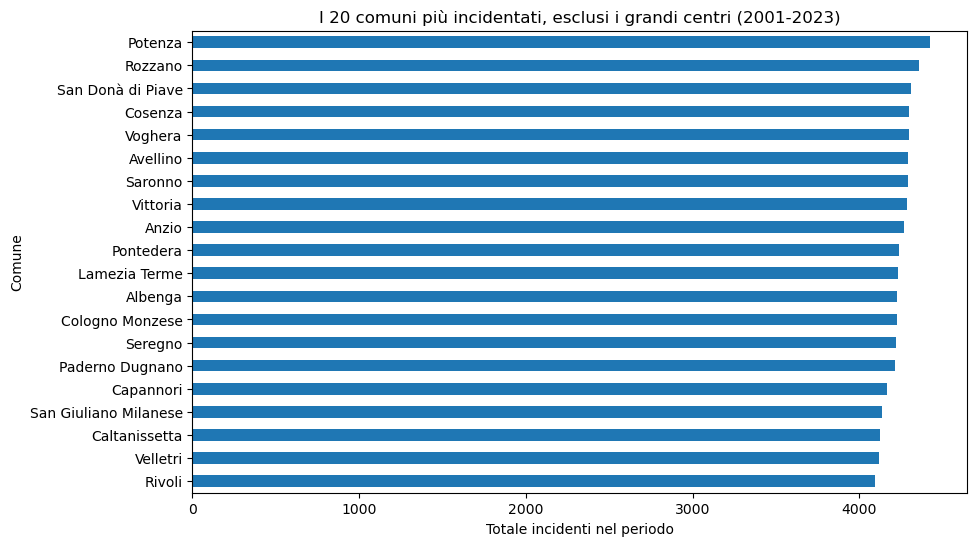

In [14]:
incidenti_per_comune_nome = df.groupby('comune')['incidenti'].sum()
comuni_sotto_soglia = incidenti_per_comune_nome[incidenti_per_comune_nome < soglia]
top_incidentati = comuni_sotto_soglia.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_incidentati.sort_values().plot(kind='barh')
plt.title('I 20 comuni più incidentati, esclusi i grandi centri (2001-2023)')
plt.xlabel('Totale incidenti nel periodo')
plt.ylabel('Comune')
plt.show()

# tolti i grandi centri sopra la soglia, raggruppo di nuovo per comune e prendo
# i 20 con più incidenti totali tra quelli rimasti. questi sono i comuni dove
# c'è più incidentalità ma che non sono tra le grandissime città già presidiate,
# quindi quelli più interessanti per capire dove conviene investire

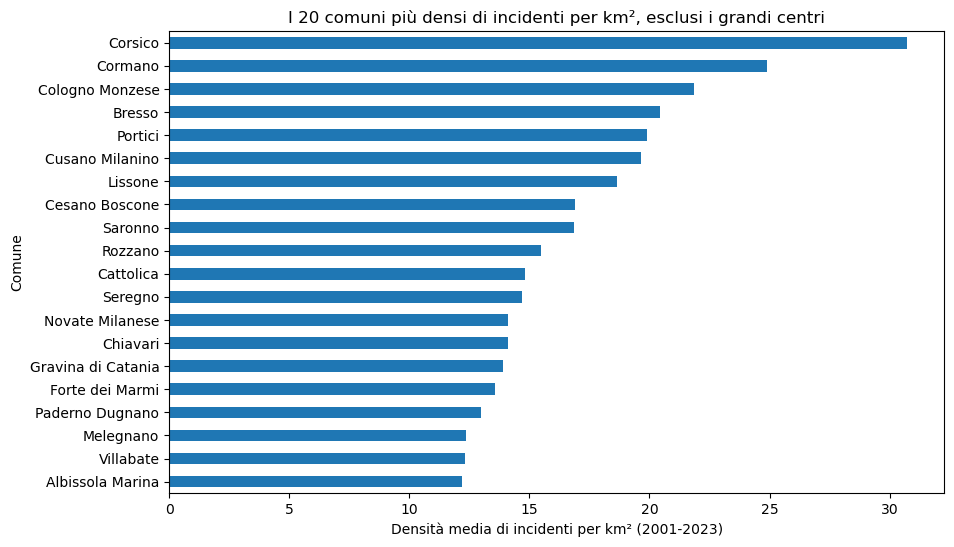

In [15]:
codici_sotto_soglia = incidenti_per_comune[incidenti_per_comune < soglia].index
df_sotto_soglia = df[df['codice_comune'].isin(codici_sotto_soglia)]

densita_media = df_sotto_soglia.groupby('comune')['incidenti_per_kmq'].mean()
top_densita = densita_media.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_densita.sort_values().plot(kind='barh')
plt.title('I 20 comuni più densi di incidenti per km², esclusi i grandi centri')
plt.xlabel('Densità media di incidenti per km² (2001-2023)')
plt.ylabel('Comune')
plt.show()

# parto dai comuni sotto soglia (esclusi i grandi centri),
# per ognuno calcolo la densità media sui 23 anni, poi ordino e prendo i top 20

# tra i comuni sotto soglia, questi sono i 20 con la densità media di incidenti
# per km² più alta. a differenza della classifica per numero assoluto, qui vedo
# dove l'incidentalità è più concentrata sul territorio, non solo dove ce n'è
# tanta in totale. così un comune piccolo ma con strade molto trafficate può
# risultare più critico di uno grande ma esteso

# Due classifiche diverse, due tipi di comuni

Mettendo a confronto la classifica per numero totale di incidenti e questa per densità per km² salta fuori una cosa interessante, le due classifiche sono popolate da comuni molto diversi.

Nella classifica per totale comandavano i capoluoghi di provincia di taglia media come Potenza, Cosenza o Avellino, comuni che hanno tanti incidenti perché hanno una loro popolazione e un loro traffico. In quella per densità invece comanda quasi tutto l'hinterland milanese, comuni come Corsico, Cormano, Cologno Monzese e Bresso, dove gli incidenti sono concentratissimi su pochi km² perché sono di fatto periferia continua di Milano.

Questo conferma che "tanti incidenti" e "incidenti concentrati" sono due cose diverse. Un capoluogo medio ha volume, ma un comune piccolo dell'hinterland ha concentrazione. Per un'azienda che vuole investire sono due profili da trattare in modo diverso perchè nei capoluoghi conviene lavorare sul volume, nei comuni piccoli e densi conviene intervenire in modo mirato su poche strade molto trafficate.

Va detto però che la densità altissima dell'hinterland milanese riflette anche il fatto che questi comuni sono di fatto Milano, contati come comuni separati. Quindi la loro concentrazione di incidenti dipende molto dalla vicinanza alla metropoli, non per forza dal fatto che siano più pericolosi di altri

# Clustering

Adesso provo a raggruppare i comuni in modo automatico in base al loro profilo di incidentalità, lasciando che sia l'algoritmo a trovare i gruppi invece di deciderli io guardando i grafici come ho fatto finora

In [16]:
codici_sotto_soglia = incidenti_per_comune[incidenti_per_comune < soglia].index
df_sotto_soglia = df[df['codice_comune'].isin(codici_sotto_soglia)]

metriche_comune = df_sotto_soglia.groupby('comune')[['incidenti_per_kmq', 'incidenti_per_1000_abitanti']].mean()
print(metriche_comune.describe())
metriche_comune

# preparo le due metriche medie per ogni comune, ma solo per i comuni sotto
# soglia (i grandi centri li ho già esclusi prima, voglio restare coerente con
# il bacino di comuni "aggredibili" su cui sto ragionando)

# per ogni comune sotto soglia calcolo densità media per km² e pro capite medio
# sui 23 anni. ottengo una riga per comune con le sue due metriche, base per
# raggrupparli in profili di incidentalità

# guardando la tabella si capisce perché uso due metriche invece di una.
# Abbadia Lariana ha densità bassa-media (1,82) ma pro capite altissimo (9,46),
# è il paese piccolo su strada pericolosa, pochi abitanti e tanti incidenti
# rispetto a loro ma non concentrati sul territorio. Abano Terme invece ha
# densità alta (3,0) e pro capite medio-alto (3,3), la cittadina trafficata con
# incidenti parecchi e anche concentrati. densità e pro capite raccontano cose
# diverse e un comune può essere alto in una e basso nell'altra, per questo le
# combino invece di guardarne una sola

       incidenti_per_kmq  incidenti_per_1000_abitanti
count        8118.000000                  8118.000000
mean            0.600111                     1.928412
std             1.443397                     1.609252
min             0.000000                     0.000000
25%             0.043478                     0.845237
50%             0.160217                     1.570000
75%             0.530652                     2.584130
max            30.733478                    24.371304


,incidenti_per_kmq,incidenti_per_1000_abitanti
comune,,
Abano Terme,3.003478,3.326087
Abbadia Cerreto,0.006957,0.158261
Abbadia Lariana,1.821739,9.464783
Abbadia San Salvatore,0.201739,1.820000
Abbasanta,0.175652,2.461739
...,...,...
Zuglio,0.024348,0.793478
Zumaglia,0.282174,0.685217
Zumpano,0.370000,1.360000


In [17]:
mediana_densita = metriche_comune['incidenti_per_kmq'].median()
mediana_procapite = metriche_comune['incidenti_per_1000_abitanti'].median()

print("mediana densità:", mediana_densita)
print("mediana pro capite:", mediana_procapite)

# calcolo la mediana delle due metriche. mi servono come soglia per dividere i
# comuni in "alto" e "basso" su ciascuna metrica. uso la mediana perché divide
# i comuni esattamente a metà

mediana densità: 0.1602173913043478
mediana pro capite: 1.5699999999999998


In [18]:
densita_alta = metriche_comune['incidenti_per_kmq'] >= mediana_densita
densita_bassa = metriche_comune['incidenti_per_kmq'] < mediana_densita
procapite_alto = metriche_comune['incidenti_per_1000_abitanti'] >= mediana_procapite
procapite_basso = metriche_comune['incidenti_per_1000_abitanti'] < mediana_procapite

print("comuni con densità alta:", densita_alta.sum())
print("comuni con densità bassa:", densita_bassa.sum())
print("comuni con pro capite alto:", procapite_alto.sum())
print("comuni con pro capite basso:", procapite_basso.sum())

# creo quattro condizioni vero/falso: per ogni comune segno se ha densità alta
# o bassa e se ha pro capite alto o basso, rispetto alla mediana. avere già
# pronte sia le condizioni "alto" che "basso" mi serve per costruire i gruppi
# in modo chiaro nella cella dopo. stampo i risultati

comuni con densità alta: 4059
comuni con densità bassa: 4059
comuni con pro capite alto: 4060
comuni con pro capite basso: 4058


In [19]:
metriche_comune.loc[densita_alta & procapite_alto, 'gruppo'] = 'alta densità - alto pro capite'
metriche_comune.loc[densita_alta & procapite_basso, 'gruppo'] = 'alta densità - basso pro capite'
metriche_comune.loc[densita_bassa & procapite_alto, 'gruppo'] = 'bassa densità - alto pro capite'
metriche_comune.loc[densita_bassa & procapite_basso, 'gruppo'] = 'bassa densità - basso pro capite'

print(metriche_comune['gruppo'].value_counts())

# combino le condizioni per assegnare a ogni comune uno dei quattro gruppi.
# ogni riga copre una combinazione, densità alta o bassa incrociata con pro capite alto o basso

gruppo
alta densità - alto pro capite      3089
bassa densità - basso pro capite    3088
bassa densità - alto pro capite      971
alta densità - basso pro capite      970
Name: count, dtype: int64


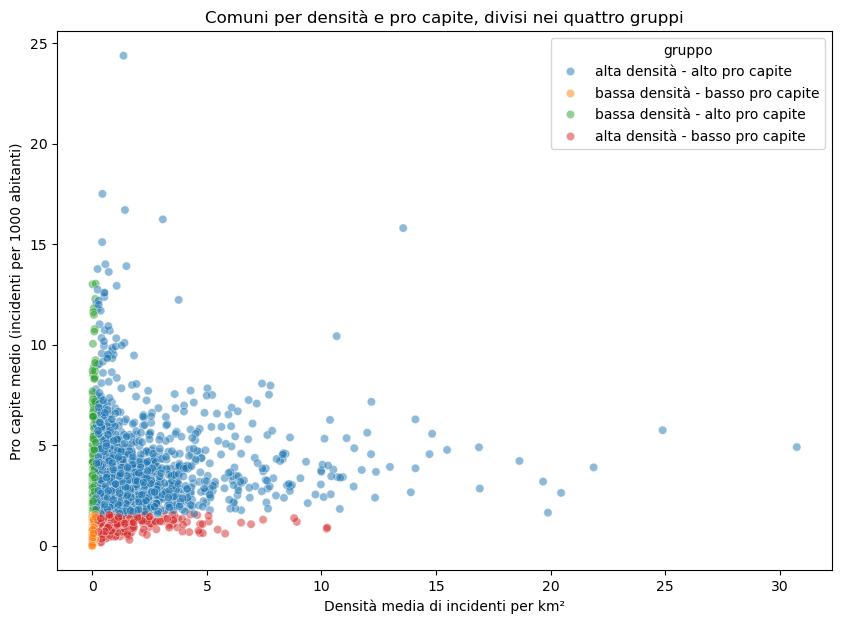

In [20]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=metriche_comune,
    x='incidenti_per_kmq',
    y='incidenti_per_1000_abitanti',
    hue='gruppo',
    alpha=0.5
)
plt.title('Comuni per densità e pro capite, divisi nei quattro gruppi')
plt.xlabel('Densità media di incidenti per km²')
plt.ylabel('Pro capite medio (incidenti per 1000 abitanti)')
plt.show()

# scatter plot con densità sull'asse x e pro capite sull'asse y, ogni comune è
# un punto colorato in base al suo gruppo. così vedo i quattro profili disposti
# nello spazio e capisco a colpo d'occhio se le due metriche vanno insieme
# (punti in diagonale) oppure no

## I 4 gruppi di comuni

Lo scatter plot divide i comuni in 4 gruppi a seconda di come stanno messi sulle 2 metriche, prendendo la mediana come linea di separazione. Abbiamo:

- Il gruppo blu (alta densità e alto pro capite) sono i comuni messi peggio su tutti e due i fronti, gli incidenti sono tanti sia rispetto al territorio sia rispetto agli abitanti. Sono quelli su cui un'azienda di sicurezza stradale dovrebbe puntare per primi, perché il problema è grosso da qualunque lato lo si guardi;

- Il gruppo arancione (bassa densità e basso pro capite) è l'opposto, comuni tranquilli dove gli incidenti sono pochi sotto entrambi gli aspetti. Sono quelli meno interessanti per investirci, il problema lì è piccolo.

- Il verde (bassa densità ma alto pro capite) sono comuni dove gli incidenti non sono concentrati sul territorio ma sono tanti rispetto a quanti ci abitano, tipo i paesi piccoli su strade molto trafficate come Abbadia Lariana;

- Il rosso (alta densità ma basso pro capite) è il contrario, incidenti concentrati sul territorio ma diluiti su una popolazione abbastanza grande da non risultare pericolosi per il singolo abitante.

In [21]:
correlazione = metriche_comune['incidenti_per_kmq'].corr(metriche_comune['incidenti_per_1000_abitanti'])
print("correlazione di Pearson densità - pro capite:", round(correlazione, 2))

# calcolo il coefficiente di correlazione di Pearson (la "r") tra densità e pro
# capite, per misurare quanto le due metriche vanno insieme. è un numero tra -1
# e 1, vicino a 1 vuol dire che salgono insieme, vicino a 0 che non sono legate,
# vicino a -1 che una sale mentre l'altra scende. Pearson misura la correlazione
# lineare, cioè quanto i punti seguono una retta

correlazione di Pearson densità - pro capite: 0.31


# Cosa dice la correlazione

La correlazione di Pearson tra densità e pro capite è 0,31, quindi positiva ma debole, le due metriche non sono molto legate, salgono insieme solo in parte e con parecchi comuni che fanno eccezione.
Ci sta perché una guarda gli incidenti rispetto al territorio, l'altra rispetto alle persone. Un comune può essere messo male su una e bene sull'altra, sono due facce del rischio che non vanno per forza insieme.
Il numero conferma quello che avevo già visto con le 3 classifiche, tutte popolate da comuni diversi, se le metriche fossero state molto correlate le classifiche si sarebbero somigliate, invece no. Ecco perché ha senso guardarle tutte e 3 invece di sceglierne solo 1

# Test d'ipotesi: permutation test e perchè
Dal clustering sono usciti due gruppi di comuni pericolosi:
- il blu (alta densità e alto pro capite);
- il verde (bassa densità ma alto pro capite).
Voglio capire se questi due gruppi hanno davvero un numero di incidenti diverso tra loro, oppure se la differenza che vedo è solo frutto del caso.
Densità e pro capite le ho già usate per costruire i gruppi, quindi testarle non avrebbe senso, faccio invece il test sul numero di incidenti, che è una cosa che non ho usato per dividere i comuni.
Uso un permutation test perché i dati sugli incidenti sono molto sbilanciati, con pochi comuni che ne hanno tanti e tanti che ne hanno pochi.
Il permutation test non ha bisogno che i dati seguano una forma particolare, a differenza di altri test, quindi è più adatto a dati fatti così

In [22]:
incidenti_medi = df_sotto_soglia.groupby('comune')['incidenti'].mean()
metriche_comune['incidenti_medi'] = incidenti_medi

blu = metriche_comune[metriche_comune['gruppo'] == 'alta densità - alto pro capite']['incidenti_medi']
verde = metriche_comune[metriche_comune['gruppo'] == 'bassa densità - alto pro capite']['incidenti_medi']

print("comuni gruppo blu:", len(blu), "- media incidenti:", round(blu.mean(), 1))
print("comuni gruppo verde:", len(verde), "- media incidenti:", round(verde.mean(), 1))
print("differenza osservata:", round(blu.mean() - verde.mean(), 1))

# aggiungo a metriche_comune il numero medio di incidenti per comune, così ho
# nello stesso posto i gruppi (già calcolati prima) e la metrica da testare.
# poi estraggo i due gruppi che mi interessano, blu e verde, prendendo solo la
# loro colonna incidenti_medi. stampo quanti comuni ci sono in ciascun gruppo,
# la loro media di incidenti e la differenza tra le due medie, che è il punto
# di partenza del test

comuni gruppo blu: 3089 - media incidenti: 26.6
comuni gruppo verde: 971 - media incidenti: 4.3
differenza osservata: 22.3


In [23]:
import numpy as np

tutti = np.concatenate([blu.values, verde.values])
n_blu = len(blu)
differenza_osservata = blu.mean() - verde.mean()

np.random.seed(42)
differenze_casuali = []
for i in range(10000):
    mescolati = np.random.permutation(tutti)
    gruppo1 = mescolati[:n_blu]
    gruppo2 = mescolati[n_blu:]
    differenze_casuali.append(gruppo1.mean() - gruppo2.mean())

differenze_casuali = np.array(differenze_casuali)
p_value = np.mean(np.abs(differenze_casuali) >= np.abs(differenza_osservata))

print("differenza osservata:", round(differenza_osservata, 2))
print("p-value:", p_value)

# unisco i valori dei due gruppi (np.concatenate) e li mescolo 10000 volte
# (np.random.permutation), ogni volta ridivido in due gruppi della stessa
# dimensione di prima e calcolo la differenza tra le medie. seed(42) serve a
# avere sempre lo stesso risultato se rilancio. il p-value conta quante volte
# il caso produce una differenza grande quanto quella vera o più

differenza osservata: 22.29
p-value: 0.0


# Il risultato del p-test
Il test conferma che i due gruppi non sono lo stesso mercato, hanno un numero di incidenti molto diverso e la differenza è reale, non casuale, questo è importante perché vuol dire che il cliente non può trattarli con un'unica strategia, sono due cose diverse:
- Sul gruppo blu, che ha un volume di incidenti molto più alto, conviene puntare se l'obiettivo è ridurre più incidenti possibile, perché è lì che il problema è numericamente più grosso.
- Sul gruppo verde invece, che ha pochi incidenti in valore assoluto ma un pro capite alto, si va per coprire comuni dove il rischio per chi ci abita è alto ma il problema è poco visibile nei numeri, quindi probabilmente meno presidiato da altri.

(Tengo a specificare che questa è una lettura di business che costruisco sopra il dato, il test dimostra solo che i due gruppi sono diversi, sta poi a me decidere cosa farne a seconda di cosa vuole ottenere l'azienda)

# Dove si trovano questi comuni
Fin'ora ho capito che esistono profili diversi di comuni pericolosi e che sono statisticamente distinti tra loro, ma mi manca un pezzo fondamentale per rispondere alla domanda del progetto, cioè dove conviene investire.

Un'azienda non lavora su un gruppo statistico, lavora su un territorio, e se i comuni di un gruppo fossero sparsi da un capo all'altro dell'Italia non avrebbe senso aprire una sede sola per servirli tutti,
per questo voglio guardare dove si trovano geograficamente i comuni più rischiosi.

Il mio dataset non ha le coordinate, quindi le prendo da una fonte esterna e le unisco ai miei dati tramite il codice ISTAT del comune, lo stesso sistema che ho già usato per la popolazione, così posso mettere ogni comune su una mappa e vedere se i gruppi pericolosi si concentrano in certe zone oppure sono sparpagliati ovunque

(fonte del dataset: https://github.com/opendatasicilia/comuni-italiani/blob/main/dati/main.csv)

In [24]:
coordinate = pd.read_csv('main.csv')
coordinate['pro_com_t'] = coordinate['pro_com_t'].astype(str).str.zfill(6)
coordinate

# carico il file con le coordinate dei comuni. metto subito il codice comune
# (pro_com_t) a stringa di 6 cifre con zfill, come ho sempre fatto,
# perché leggendo il csv perderebbe gli zeri davanti. stampo tutto per vedere com'è fatto il file

,comune,pro_com_t,lat,long,den_prov,sigla,den_reg,cod_reg,cap,cf,pec,mail,sito_web,wikipedia,stemma
0,Agliè,001001,45.367055,7.766918,Torino,TO,Piemonte,1,10011.0,8.350179e+10,protocollo@pec.comune.aglie.to.it,protocollo@comune.aglie.to.it,http://comune.aglie.to.it,https://it.wikipedia.org/wiki/Agliè,https://raw.githubusercontent.com/opendatasici...
1,Airasca,001002,44.917042,7.484321,Torino,TO,Piemonte,1,10060.0,8.500291e+10,airasca@postemailcertificata.it,protocollo@comune.airasca.to.it,http://comune.airasca.to.it,https://it.wikipedia.org/wiki/Airasca,https://raw.githubusercontent.com/opendatasici...
2,Ala di Stura,001003,45.315150,7.305909,Torino,TO,Piemonte,1,10070.0,8.300297e+10,comunealadistura@pec.it,NaN,http://comunealadistura.it,https://it.wikipedia.org/wiki/Ala_di_Stura,https://raw.githubusercontent.com/opendatasici...
3,Albiano d'Ivrea,001004,45.432959,7.950621,Torino,TO,Piemonte,1,10010.0,1.735420e+09,albiano.divrea@cert.ruparpiemonte.it,albiano.divrea@ruparpiemonte.it,http://comune.albianodivrea.to.it,https://it.wikipedia.org/wiki/Albiano_d'Ivrea,https://raw.githubusercontent.com/opendatasici...
4,Almese,001006,45.116876,7.394550,Torino,TO,Piemonte,1,10040.0,1.817670e+09,comune.almese.to@cert.legalmail.it,segreteria@comune.almese.to.it,http://comune.almese.to.it,https://it.wikipedia.org/wiki/Almese,https://raw.githubusercontent.com/opendatasici...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7899,Villaputzu,111103,39.441045,9.573951,Sud Sardegna,SU,Sardegna,20,9040.0,8.000317e+10,protocollo@pec.comune.villaputzu.ca.it,NaN,http://comune.villaputzu.ca.it,https://it.wikipedia.org/wiki/Villaputzu,https://raw.githubusercontent.com/opendatasici...
7900,Villasalto,111104,39.492145,9.393047,Sud Sardegna,SU,Sardegna,20,9040.0,1.391411e+09,protocollo.villasalto@pec.comunas.it,anagrafe@comune.villasalto.ca.it,http://comune.villasalto.ca.it,https://it.wikipedia.org/wiki/Villasalto,https://raw.githubusercontent.com/opendatasici...
7901,Villasimius,111105,39.143140,9.520854,Sud Sardegna,SU,Sardegna,20,9049.0,8.001417e+10,protocollo.comunevillasimius@legalmail.it,NaN,http://comune.villasimius.ca.it,https://it.wikipedia.org/wiki/Villasimius,https://raw.githubusercontent.com/opendatasici...
7902,Villasor,111106,39.380439,8.942839,Sud Sardegna,SU,Sardegna,20,9034.0,8.200216e+10,segreteriavillasor@legalmail.it,segreteria@comune.villasor.ca.it,http://comune.villasor.gov.it,https://it.wikipedia.org/wiki/Villasor,https://raw.githubusercontent.com/opendatasici...


In [25]:
coordinate = coordinate[['comune', 'pro_com_t', 'lat', 'long', 'sigla', 'den_reg']]

coordinate = coordinate.rename(columns={
    'pro_com_t': 'codice_comune',
    'lat': 'latitudine',
    'long': 'longitudine',
    'den_reg': 'regione'
})

assert list(coordinate.columns) == ['comune', 'codice_comune', 'latitudine', 'longitudine', 'sigla', 'regione']
coordinate

# tengo solo le colonne che mi servono e le rinomino per coerenza col mio
# dataset e per chiarezza (latitudine e longitudine per esteso). l'assert
# controlla che le colonne siano esattamente quelle giuste prima di andare avanti

,comune,codice_comune,latitudine,longitudine,sigla,regione
0,Agliè,001001,45.367055,7.766918,TO,Piemonte
1,Airasca,001002,44.917042,7.484321,TO,Piemonte
2,Ala di Stura,001003,45.315150,7.305909,TO,Piemonte
3,Albiano d'Ivrea,001004,45.432959,7.950621,TO,Piemonte
4,Almese,001006,45.116876,7.394550,TO,Piemonte
...,...,...,...,...,...,...
7899,Villaputzu,111103,39.441045,9.573951,SU,Sardegna
7900,Villasalto,111104,39.492145,9.393047,SU,Sardegna
7901,Villasimius,111105,39.143140,9.520854,SU,Sardegna
7902,Villasor,111106,39.380439,8.942839,SU,Sardegna


In [26]:
coordinate.info()

# guardo i tipi di ogni colonna e se ci sono valori mancanti. mi interessa
# soprattutto che latitudine e longitudine siano numeri (float), perché se
# fossero testo non potrei usarle per la mappa

<class 'pandas.DataFrame'>
RangeIndex: 7904 entries, 0 to 7903
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   comune         7903 non-null   str    
 1   codice_comune  7904 non-null   str    
 2   latitudine     7904 non-null   float64
 3   longitudine    7904 non-null   float64
 4   sigla          7812 non-null   str    
 5   regione        7904 non-null   str    
dtypes: float64(2), str(4)
memory usage: 370.6 KB


# Il riferimento
Per capire se le coordinate sono giuste mi servo di un riferimento esterno, cioè i confini geografici reali dell'Italia. Cercando online, l'Italia si estende in latitudine da circa 36° (estremità sud, vicino a Ragusa) a circa 47° (estremità nord, sulle Alpi), e in longitudine da circa 6,6° (ovest, vicino a Bardonecchia) a circa 18,5° (est, vicino a Otranto), quindi ogni comune italiano deve avere latitudine tra 36 e 47 e longitudine tra 6 e 18 circa.
Se nei miei dati trovo valori fuori da questo range, vuol dire che quelle coordinate sono sbagliate

In [27]:
print("LATITUDINE - min:", coordinate['latitudine'].min(), "max:", coordinate['latitudine'].max())
print("LONGITUDINE - min:", coordinate['longitudine'].min(), "max:", coordinate['longitudine'].max())

# confronto i valori minimi e massimi delle coordinate col range reale
# dell'Italia (latitudine 36-47, longitudine 6-18). i minimi rientrano nel
# range, quindi sono coerenti. i massimi invece sono enormemente fuori, segno
# che alcune righe hanno coordinate sbagliate nel file

LATITUDINE - min: 35.511134 max: 45631.0
LONGITUDINE - min: 6.703205 max: 16248.0


In [28]:
fuori_range = coordinate[
    (coordinate['latitudine'] < 35) | (coordinate['latitudine'] > 48) |
    (coordinate['longitudine'] < 6) | (coordinate['longitudine'] > 19)
]
print("comuni con coordinate fuori range:", len(fuori_range))
fuori_range[['codice_comune', 'comune', 'latitudine', 'longitudine', 'regione']]

# conto quante righe hanno coordinate fuori dal range italiano (lat 36-47,
# long 6-18, con un po' di margine). così vedo quante sono rovinate e quali
# comuni, per decidere se conviene sistemarle o toglierle

comuni con coordinate fuori range: 11


,codice_comune,comune,latitudine,longitudine,regione
1159,103056,Premia,46.268144,8339.000000,Piemonte
1360,012108,Olgiate Olona,45631.000000,8.889841,Lombardia
2431,019049,Gombito,45.261556,9728.000000,Lombardia
3492,028041,Gazzo,45581.000000,11.706548,Veneto
4365,099009,Montegridolfo,43859.000000,12.688511,Emilia-Romagna
4568,051021,Lucignano,43.274463,11746.000000,Toscana
5748,094007,Carovilli,41.714248,14294.000000,Molise
5971,062074,Telese Terme,41.216414,14527.000000,Campania
7092,102007,Dasà,38.564879,16196.000000,Calabria
7131,102046,Vazzano,38.632881,16248.000000,Calabria


In [29]:
coordinate.loc[coordinate['codice_comune'] == '103056', 'longitudine'] = 8.339    # Premia
coordinate.loc[coordinate['codice_comune'] == '012108', 'latitudine'] = 45.631    # Olgiate Olona
coordinate.loc[coordinate['codice_comune'] == '019049', 'longitudine'] = 9.728    # Gombito
coordinate.loc[coordinate['codice_comune'] == '028041', 'latitudine'] = 45.581    # Gazzo
coordinate.loc[coordinate['codice_comune'] == '099009', 'latitudine'] = 43.859    # Montegridolfo
coordinate.loc[coordinate['codice_comune'] == '051021', 'longitudine'] = 11.746   # Lucignano
coordinate.loc[coordinate['codice_comune'] == '094007', 'longitudine'] = 14.294   # Carovilli
coordinate.loc[coordinate['codice_comune'] == '062074', 'longitudine'] = 14.527   # Telese Terme
coordinate.loc[coordinate['codice_comune'] == '102007', 'longitudine'] = 16.196   # Dasà
coordinate.loc[coordinate['codice_comune'] == '102046', 'longitudine'] = 16.248   # Vazzano
coordinate.loc[coordinate['codice_comune'] == '091002', 'longitudine'] = 9.527    # Arzana

# correggo a mano le coordinate degli 11 comuni dove nel file mancava il punto
# decimale (es. 45631 invece di 45.631). uso il codice comune per individuare
# ognuno e correggo solo la coordinata sbagliata, lat o long a seconda del caso.
# le coordinate corrette le ho verificate online

In [30]:
print("LATITUDINE - min:", coordinate['latitudine'].min(), "max:", coordinate['latitudine'].max())
print("LONGITUDINE - min:", coordinate['longitudine'].min(), "max:", coordinate['longitudine'].max())

LATITUDINE - min: 35.511134 max: 47.040741
LONGITUDINE - min: 6.703205 max: 18.485933


Ho trovato 11 comuni con coordinate fuori dal range italiano. Guardandoli si capisce che il problema era sempre lo stesso, nel file mancava il punto decimale, per cui un valore come 45.631 era diventato 45631, visto che erano pochi li ho corretti a mano uno per uno, rimettendo il punto al posto giusto e verificando le coordinate online.
Dopo la correzione il minimo e il massimo di latitudine e longitudine rientrano nel range reale dell'Italia, quindi ora i dati sono puliti al millimetro

In [31]:
print("righe totali:", len(coordinate))
print("nomi comune unici:", coordinate['comune'].nunique())
print("differenza (nomi doppi):", len(coordinate) - coordinate['comune'].nunique())

righe totali: 7904
nomi comune unici: 7897
differenza (nomi doppi): 7


In [32]:
nomi_doppi = coordinate[coordinate['comune'].duplicated(keep=False)]
nomi_doppi.sort_values('comune')[['comune', 'codice_comune', 'sigla', 'regione']]

# trovo i comuni che hanno un nome ripetuto. duplicated(keep=False) segna tutte
# le righe con nome doppio (non solo i duplicati successivi), così le vedo tutte
# in coppia. le ordino per nome per confrontarle facilmente

,comune,codice_comune,sigla,regione
741,Calliano,005014,AT,Piemonte
2897,Calliano,022035,TN,Trentino-Alto Adige/Südtirol
1812,Castro,016065,BG,Lombardia
6588,Castro,075096,LE,Puglia
1469,Livo,013130,CO,Lombardia
2940,Livo,022106,TN,Trentino-Alto Adige/Südtirol
1494,Peglio,013178,CO,Lombardia
4779,Peglio,041041,PU,Marche
230,Samone,001235,TO,Piemonte
2981,Samone,022165,TN,Trentino-Alto Adige/Südtirol


# Questo controllo mi ha fatto venire in mente il piccolo errore che ho spiegato nella cella markdown sotto queste altre 2 celle di codice

In [33]:
nomi_to_codici = df.groupby('comune')['codice_comune'].nunique()
problematici = nomi_to_codici[nomi_to_codici > 1]
print("nomi-comune con più di un codice nel dataset:", len(problematici))
print(problematici)

# controllo se nel mio dataset ci sono nomi di comune che corrispondono a più
# codici diversi, cioè veri omonimi che il groupby per nome avrebbe fuso. se escono 0, non ci sono
# nomi di comuni omonimi, altrimenti ci sono

nomi-comune con più di un codice nel dataset: 294
comune
Aggius            2
Aglientu          2
Agrate Brianza    2
Aicurzio          2
Albiate           2
                 ..
Villasanta        2
Villasimius       2
Villasor          2
Villaspeciosa     2
Vimercate         2
Name: codice_comune, Length: 294, dtype: int64


In [ ]:
for nome in ['Agrate Brianza', 'Vimercate']:
    print(f"\n=== {nome} ===")
    righe = df[df['comune'] == nome]
    for codice in righe['codice_comune'].unique():
        sotto = righe[righe['codice_comune'] == codice]
        print(codice, "| provincia:", sotto['sigla'].unique(), "| anni:", sotto['anno'].min(), "-", sotto['anno'].max())

# per due comuni che risultano con due codici guardo, per ciascun codice, la
# provincia e gli anni coperti. si vede che Agrate Brianza e Vimercate hanno un
# codice con provincia MI (Milano) fino al 2008 e un altro con provincia MB
# (Monza-Brianza) dal 2010, senza sovrapposizioni. è la prova che non sono due
# comuni diversi ma lo stesso comune che ha cambiato codice quando è passato
# alla provincia di Monza-Brianza, diventata operativa nel 2009. il groupby per
# nome li tiene giustamente uniti


=== Agrate Brianza ===
015003 | provincia: <StringArray>
['MI']
Length: 1, dtype: str | anni: 2001 - 2008
108001 | provincia: <StringArray>
['MB']
Length: 1, dtype: str | anni: 2010 - 2023

=== Vimercate ===
015241 | provincia: <StringArray>
['MI']
Length: 1, dtype: str | anni: 2001 - 2008
108050 | provincia: <StringArray>
['MB']
Length: 1, dtype: str | anni: 2010 - 2023


# Una verifica sui comuni doppi

Preparando il merge con le coordinate ho visto che nel file geografico c'erano 7 comuni con lo stesso nome ma in province diverse. La cosa mi ha insospettito, se succede lì potrebbe succedere anche nei miei dati, dove ho raggruppato per nome. Non ci avevo pensato prima, quindi sono andato a controllare

Sono usciti 294 nomi con due codici ISTAT diversi, a guardarli bene però non sono comuni diversi con lo stesso nome, è lo stesso comune che nel tempo ha cambiato codice. Agrate Brianza ad esempio ne ha uno dal 2001 al 2008 e un altro dal 2010 al 2023, perché nel 2009 è nata la provincia di Monza-Brianza e diversi comuni sono passati da Milano alla provincia nuova cambiando codice, idem per un po' di comuni sardi dopo il riordino delle loro province.

Non me lo aspettavo, ma per fortuna il fatto di aver raggruppato per nome, cosa che avevo fatto per tenere ogni comune sotto un'unica voce, regge bene anche qui, ogni comune resta intero con tutti i suoi 23 anni, mentre raggruppando per codice l'avrei spezzato in due. L'unico neo è che quando riporto il codice sul nome per prendere le coordinate ne becco uno solo dei due, ma tanto le coordinate del comune sono le stesse per entrambi, quindi sulla mappa finisce comunque al posto giusto.

# Ora procedo col merge
Per vedere quali e quanti comuni hanno le coordinate e capire come lavorare successivamente

In [37]:
metriche_geo = metriche_comune.merge(coordinate, left_index=True, right_on='comune', how='left')
print("comuni senza coordinate:", metriche_geo['latitudine'].isnull().sum())
metriche_geo

# attacco le coordinate a metriche_comune usando il nome del comune. il fatto è
# che il nome sta in posti diversi nelle due tabelle, in metriche_comune è
# l'indice e in coordinate è una colonna normale. quindi uso left_index=True per
# dire "a sinistra prendi l'indice" e right_on='comune' per dire "a destra prendi
# la colonna comune", così le abbina tra loro. how='left' mi tiene tutti i comuni
# del clustering. poi guardo quanti sono rimasti senza coordinate e stampo tutto

comuni senza coordinate: 467


,incidenti_per_kmq,incidenti_per_1000_abitanti,gruppo,incidenti_medi,comune,codice_comune,latitudine,longitudine,sigla,regione
3454.0,3.003478,3.326087,alta densità - alto pro capite,64.347826,Abano Terme,028001,45.360314,11.789783,PD,Veneto
2646.0,0.006957,0.158261,bassa densità - basso pro capite,0.043478,Abbadia Cerreto,098001,45.311912,9.594212,LO,Lombardia
2562.0,1.821739,9.464783,alta densità - alto pro capite,30.347826,Abbadia Lariana,097001,45.900045,9.334056,LC,Lombardia
4586.0,0.201739,1.820000,alta densità - alto pro capite,11.956522,Abbadia San Salvatore,052001,42.880972,11.672420,SI,Toscana
7710.0,0.175652,2.461739,alta densità - alto pro capite,6.913043,Abbasanta,095001,40.126752,8.818027,OR,Sardegna
...,...,...,...,...,...,...,...,...,...,...
3733.0,0.024348,0.793478,bassa densità - basso pro capite,0.478261,Zuglio,030136,46.461796,13.026040,UD,Friuli-Venezia Giulia
1102.0,0.282174,0.685217,alta densità - basso pro capite,0.739130,Zumaglia,096083,45.593864,8.089421,BI,Piemonte
6879.0,0.370000,1.360000,alta densità - basso pro capite,3.000000,Zumpano,078155,39.310894,16.292094,CS,Calabria
6184.0,0.000000,0.000000,bassa densità - basso pro capite,0.000000,Zungoli,064120,41.125322,15.203648,AV,Campania


In [38]:
senza_coord = metriche_geo[metriche_geo['latitudine'].isnull()]
print(senza_coord['gruppo'].value_counts())

# guardo a quali gruppi appartengono i comuni rimasti senza coordinate. se sono
# quasi tutti tranquilli (bassa-bassa) li posso togliere senza problemi, se ci
# sono tanti comuni dei gruppi pericolosi (blu e verde) devo pensarci

gruppo
alta densità - alto pro capite      168
bassa densità - basso pro capite    157
bassa densità - alto pro capite     107
alta densità - basso pro capite      35
Name: count, dtype: int64


In [ ]:
senza_coord = metriche_geo[metriche_geo['latitudine'].isnull()]
print(senza_coord['comune'].head(20).tolist())

# guardo i nomi dei primi comuni senza coordinate, per capire se magari è un problema
# di nomi scritti diversamente (accenti, apostrofi) o di codici cambiati, o altro

['Abetone', 'Acquacanina', 'Acquarica del Capo', 'Aldino/Aldein', 'Alice Superiore', 'Alluvioni Cambiò', 'Amblar', 'Andriano/Andrian', 'Anterivo/Altrei', 'Appiano sulla strada del vino/Eppan an der Weinstraße', 'Arzene', 'Auditore', 'Avelengo/Hafling', 'Badia/Abtei', 'Barbarano Vicentino', "Barberino Val d'Elsa", 'Barbiano/Barbian', 'Barchi', 'Bardello con Malgesso e Bregano', "Bastida de' Dossi"]


Dopo il merge mi restano 467 comuni senza coordinate, ma prima di buttarli mi sono chiesto se non ce ne fosse qualcuno che mi serviva, così ho guardato a che gruppi appartenevano e in effetti c'erano parecchi blu e verdi, quindi sono andato a vedere i nomi per capire perché mancavano

Sono di due tipi, alcuni sono comuni dell'Alto Adige col nome doppio italiano-tedesco tipo Aldino/Aldein, che nei miei dati stanno solo in italiano e il merge non li aggancia, altri sono comuni che nel tempo sono stati accorpati ad altri, quindi ci sono nei miei dati vecchi ma non nel file coordinate di oggi.

Recuperarli o non si può (quelli fusi non esistono più) o sarebbe un lavoro a parte, tanto sono il 6% e sparsi ovunque, li tolgo e lo faccio notare, visto che con 7600 comuni la mappa fa comunque il suo lavoro

In [42]:
metriche_geo = metriche_geo[metriche_geo['latitudine'].notnull()]
print(metriche_geo.shape)

# tolgo i comuni senza coordinate, quelli con nome bilingue o accorpati nel
# tempo che il merge non ha agganciato. senza latitudine e longitudine non
# posso metterli sulla mappa

(7657, 10)


In [43]:
print("comuni:", len(metriche_geo))
print("nomi unici:", metriche_geo['comune'].nunique())
print("doppioni:", len(metriche_geo) - metriche_geo['comune'].nunique())

# controllo se dopo il merge ci sono righe doppie per lo stesso comune, create
# dai comuni omonimi del file coordinate

comuni: 7657
nomi unici: 7651
doppioni: 6


In [ ]:
metriche_geo = metriche_geo.drop_duplicates('comune')
print(metriche_geo.shape)

# tolgo le 6 righe doppie create dai comuni omonimi del file coordinate (comuni
# diversi con lo stesso nome, tipo i due Castro, o Livo, in province diverse). con
# drop_duplicates tengo una sola riga per nome, quindi per questi 6 viene presa
# una delle due province a caso. sono pochissimi e per una mappa d'insieme non
# cambiano niente, quindi va bene così

(7651, 10)


# Mappa dei comuni italiani e rappresentazione grafica gruppi di rischio

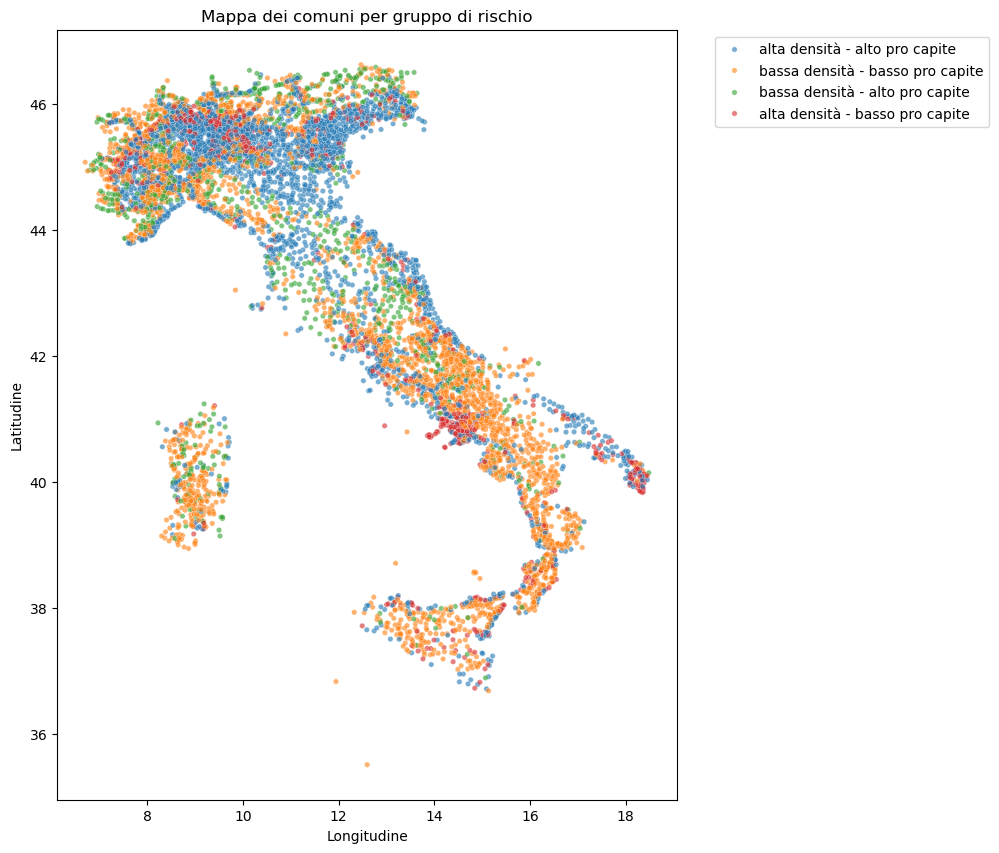

In [45]:
plt.figure(figsize=(8, 10))
sns.scatterplot(
    data=metriche_geo,
    x='longitudine',
    y='latitudine',
    hue='gruppo',
    s=15,
    alpha=0.6
)
plt.title('Mappa dei comuni per gruppo di rischio')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# metto ogni comune sulla mappa con longitudine e latitudine come assi, colorato
# per gruppo. figsize verticale perché l'Italia è più alta che larga, punti
# piccoli (s=15) e un po' trasparenti (alpha) perché sono tanti, legenda spostata
# fuori per non coprire la mappa. così vedo se i gruppi pericolosi si concentrano
# in certe zone

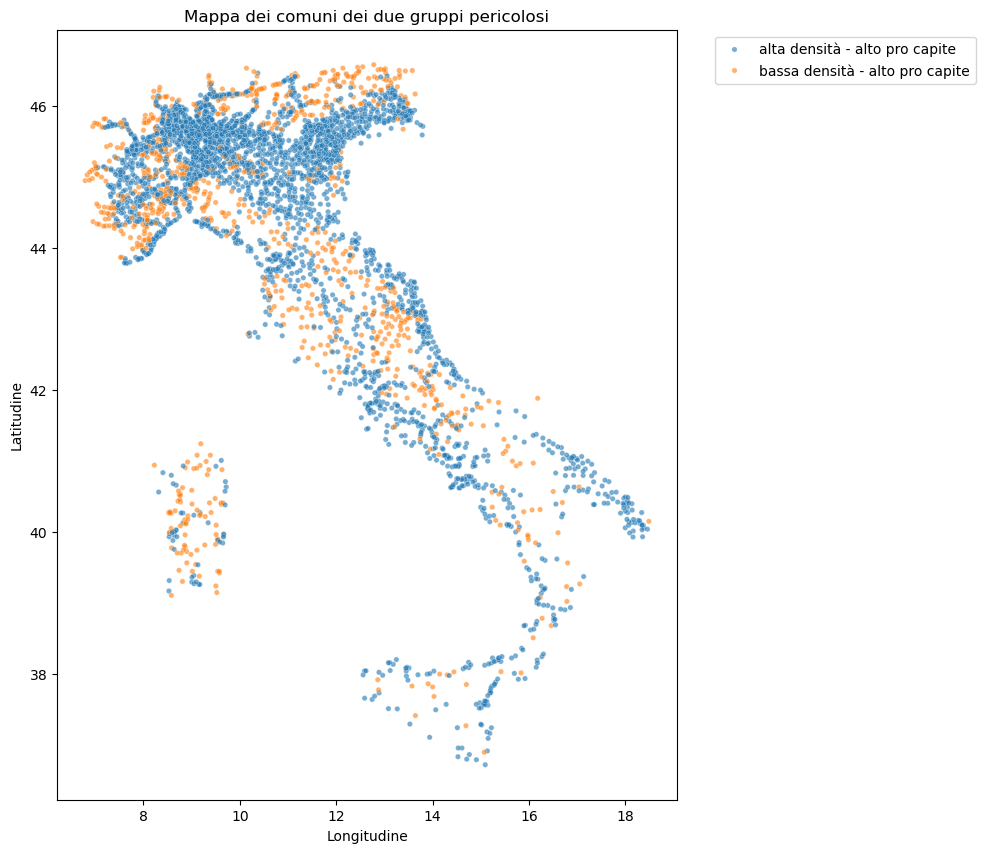

In [46]:
due_gruppi = metriche_geo[
    (metriche_geo['gruppo'] == 'alta densità - alto pro capite') |
    (metriche_geo['gruppo'] == 'bassa densità - alto pro capite')
]

plt.figure(figsize=(8, 10))
sns.scatterplot(
    data=due_gruppi,
    x='longitudine',
    y='latitudine',
    hue='gruppo',
    s=15,
    alpha=0.6
)
plt.title('Mappa dei comuni dei due gruppi pericolosi')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# ora che la mappa funziona, tengo solo i due gruppi su cui voglio lavorare,
# blu (alta densità e alto pro capite) e verde (bassa densità ma alto pro capite),
# e li metto sulla mappa come prima. così vedo dove si concentrano
# senza avere sulla cartina gli altri due gruppi

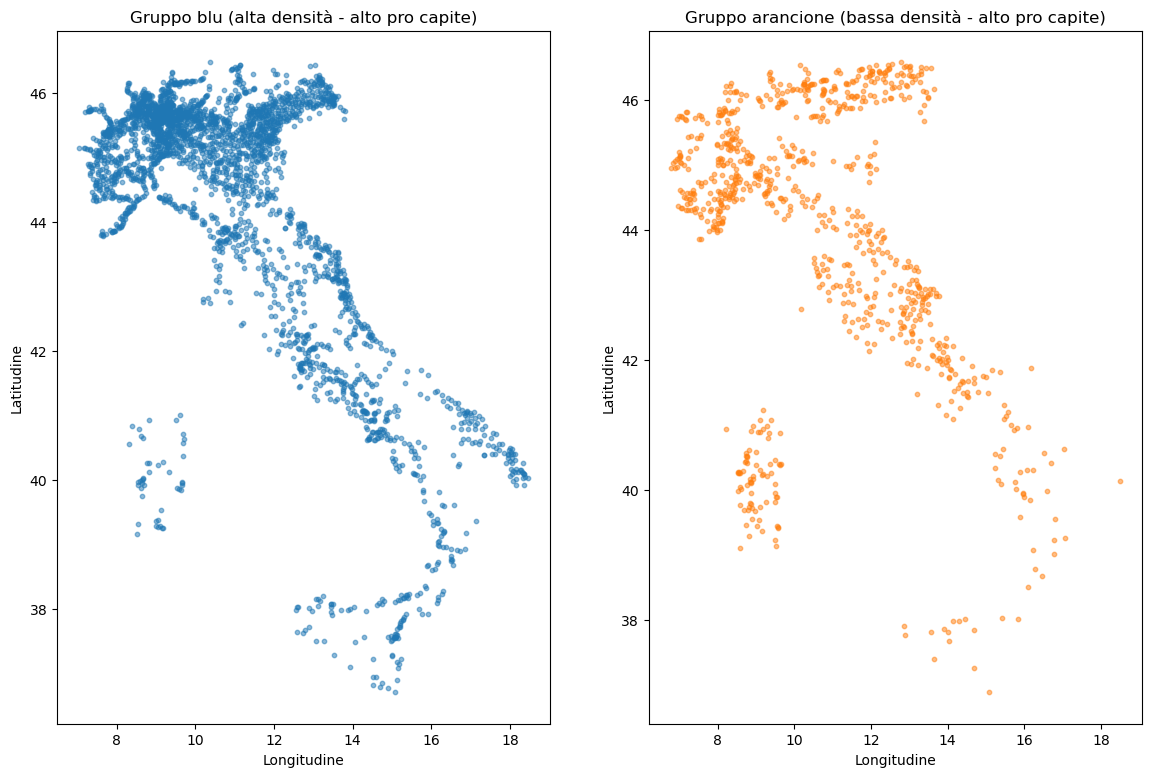

In [51]:
blu = metriche_geo[metriche_geo['gruppo'] == 'alta densità - alto pro capite']
arancio = metriche_geo[metriche_geo['gruppo'] == 'bassa densità - alto pro capite']

fig, assi = plt.subplots(1, 2, figsize=(14, 9))

assi[0].scatter(blu['longitudine'], blu['latitudine'], s=10, alpha=0.5, color='tab:blue')
assi[0].set_title('Gruppo blu (alta densità - alto pro capite)')
assi[0].set_xlabel('Longitudine')
assi[0].set_ylabel('Latitudine')

assi[1].scatter(arancio['longitudine'], arancio['latitudine'], s=10, alpha=0.5, color='tab:orange')
assi[1].set_title('Gruppo arancione (bassa densità - alto pro capite)')
assi[1].set_xlabel('Longitudine')
assi[1].set_ylabel('Latitudine')

plt.show()

# metto i due gruppi pericolosi su due mappe affiancate, una per gruppo, così li
# confronto senza che i punti si sovrappongano. subplots(1, 2) crea una riga con
# due grafici, assi[0] è quello di sinistra e assi[1] quello di destra

In [50]:
blu = metriche_geo[metriche_geo['gruppo'] == 'alta densità - alto pro capite']
arancio = metriche_geo[metriche_geo['gruppo'] == 'bassa densità - alto pro capite']

print("=== gruppo blu ===")
print(blu['regione'].value_counts().head(15))
print("\=== gruppo arancione ===")
print(arancio['regione'].value_counts().head(15))

# conto quanti comuni dei due gruppi pericolosi ci sono per regione, per vedere
# con un numero preciso dove si concentrano invece che a occhio sulla mappa

=== gruppo blu ===
regione
Lombardia                       807
Veneto                          378
Piemonte                        377
Emilia-Romagna                  203
Toscana                         127
Lazio                           123
Friuli-Venezia Giulia           117
Campania                        108
Marche                          104
Puglia                          101
Liguria                          97
Sicilia                          86
Abruzzo                          69
Calabria                         54
Trentino-Alto Adige/Südtirol     50
Name: count, dtype: int64
\=== gruppo arancione ===
regione
Piemonte                        187
Lombardia                        98
Sardegna                         77
Toscana                          61
Emilia-Romagna                   52
Veneto                           50
Trentino-Alto Adige/Südtirol     46
Marche                           44
Friuli-Venezia Giulia            42
Liguria                          32
Lazio        

<>:6: SyntaxWarning: invalid escape sequence '\='
<>:6: SyntaxWarning: invalid escape sequence '\='
C:\Users\vessi\AppData\Local\Temp\ipykernel_35020\255746451.py:6: SyntaxWarning: invalid escape sequence '\='
  print("\=== gruppo arancione ===")


Dal print si vede che la Lombardia è nettamente in testa per quanto riguarda il gruppo più pericoloso, il blu (alta densità - alto pro capite), ora entro nel dettaglio per vedere esattamente le province più coinvolte

In [52]:
blu_lombardia = blu[blu['regione'] == 'Lombardia']
print(blu_lombardia['sigla'].value_counts())

# tra i comuni blu tengo solo quelli lombardi e li conto per provincia (sigla),
# per vedere in che zona della Lombardia si concentra di più il rischio

sigla
MI    106
BS    104
BG     98
PV     87
VA     82
CO     74
CR     65
LC     49
MN     49
MB     39
SO     34
LO     20
Name: count, dtype: int64


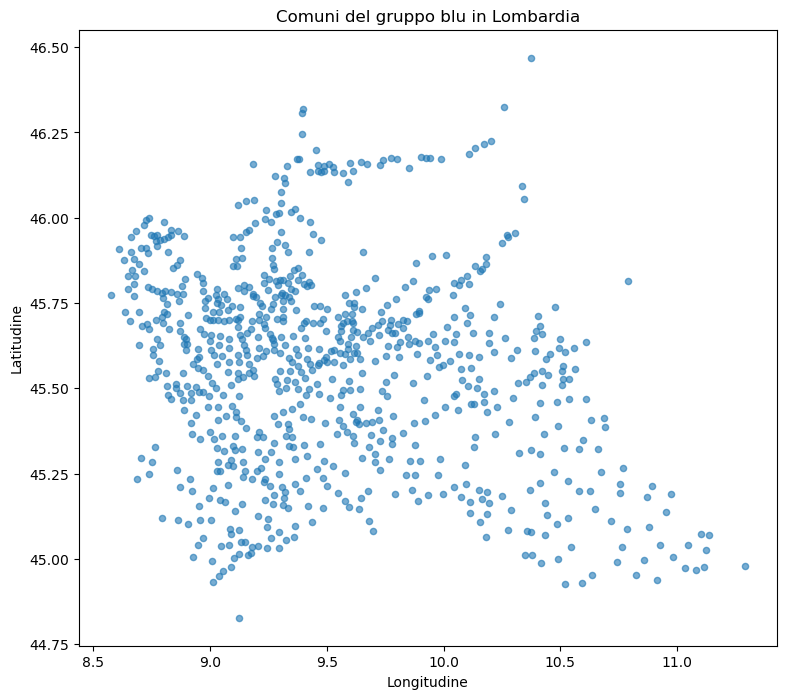

In [54]:
plt.figure(figsize=(9, 8))
plt.scatter(blu_lombardia['longitudine'], blu_lombardia['latitudine'], s=20, alpha=0.6, color='tab:blue')
plt.title('Comuni del gruppo blu in Lombardia')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.show()

# metto sulla mappa solo i comuni blu della Lombardia, usando le loro coordinate.
# così vedo in che zona della regione si concentrano, se in una fascia precisa
# o sparsi un po' ovunque

# Risposta alla business question "Dove conviene investire?"
Mettendo insieme le mappe e i conteggi il quadro è chiaro, il gruppo blu, quello più pericoloso perché messo male sia come densità che come pro capite, si concentra nettamente al Nord, e su tutte spicca la Lombardia con 807 comuni, più del doppio della seconda regione

Scendendo nel dettaglio delle province lombarde non c'è una zona sola che domina, le prime 3 zone sono molto simili tra loro:
- Milano con 106 comuni,
- Brescia con 104,
- Bergamo con 98.

Sostanzialmente la fascia più fitta è lungo l'asse Milano-Bergamo-Brescia, seeguiti da Pavia, Varese e Como.

Per l'azienda questo vuol dire che la Lombardia è la scelta più sensata dove partire, e in particolare la fascia pedemontana centrale, perché lì c'è la maggiore concentrazione di comuni ad alto rischio vicini tra loro, quindi servibili da un'unica sede senza doversi spostare da un capo all'altro d'Italia. Va comunque tenuto presente che la Lombardia è anche la regione con più comuni in assoluto, quindi parte di questo record dipende anche dalla sua dimensione, non solo dal fatto di essere più pericolosa